In [6]:
import jax.numpy as jnp 
import jax
import matplotlib.pyplot as plt
import pandas as pd
import time

In [7]:
# u_t + a u_x = 0, com a>0
inicio = time.time()
a = 0.8

N = 202
M = 101


xi = 0.0
xf = 10.0
dx = (xf - xi) /(N-1)
x = jnp.linspace(xi, xf, N)

ti = 0.0 
tf = 5.0
t = jnp.linspace(ti, tf, M)

#h = 0.04

h = t[1] - t[0]
lmbd = a * h / dx
cond = 1


In [8]:
def condicao_inicial(x,index):
    match index :
        case 0:
            return jnp.where((x >= 1) & (x <= 2), 1.0, 0.0)
    
        case 1:
            return (jnp.sin(x*jnp.pi))**4
   
        case 2:
            # return jnp.where((x >= 1) & (x <= 2),jnp.exp(-x**2),0.0)
            return jnp.exp(-(x-2)**2)



def solucao_exata(x,t,a,index):
    return condicao_inicial(x-a*t,index)




def passo_upwind(u,t):
    
    u_new = (1-lmbd)*u[1:] + lmbd*u[:-1]
    u = u.at[1:].set(u_new)
    u = u.at[0].set(u[-1])
    


    
    return u, u



def passo_lax_wendroff(u,t):
    
    u_esq = jnp.roll(u,1)
    u_dir = jnp.roll(u,-1)
    
    u_new = ((-1/2)*lmbd*(1-lmbd)*u_esq)+ ((1 - lmbd**2)*u) + ((1/2)*lmbd*(1+lmbd)*u_dir)
    # u = u.at[1:-1].set(u_new)
    
    # a = u[0]
    
    # u = u.at[0].set(u[-1])
    # u = u.at[-1].set(u[0])

    

    return u_new, u_new


u0 = jnp.zeros(N)
u0 = u0.at[:].set(condicao_inicial(x,cond))


solucao_upwind, historico_upwind = jax.lax.scan(passo_upwind, u0, t)
solucao_lax_wendroff, historico_lax_wendroff = jax.lax.scan(passo_lax_wendroff,u0,t)

fim = time.time()

print("Tempo total de execução {}".format(fim-inicio))
print(jnp.shape(historico_upwind))
print(jnp.shape(historico_lax_wendroff))
print(jnp.shape(solucao_upwind))

Tempo total de execução 0.21226882934570312
(101, 202)
(101, 202)
(202,)


aparentemente a segunda varivél retornada na função passo que vai pro jax, vira uma matriz que guarda a solução no tempo e no espaço, da pra retornar None pra não armazenar coisa dms  
além disso, creio que nao seja o ideal fazer duas funções passo, mas não consegui junta-las em uma só


In [9]:

area_upwind_inicial = jnp.trapezoid(historico_upwind[0])
area_lax_wendroff_inicial = jnp.trapezoid(historico_lax_wendroff[0])
area_exata_inicial= jnp.trapezoid(solucao_exata(x,t[0],a,cond))

area_upwind_final = jnp.trapezoid(solucao_upwind)
area_lax_wendroff_final = jnp.trapezoid(solucao_lax_wendroff)
area_exata_final= jnp.trapezoid(solucao_exata(x,t[-1],a,cond))

variacao_exata = area_exata_final - area_exata_inicial  
variacao_upwind = area_upwind_final - area_upwind_inicial
variacao_lax_wendroff =  area_lax_wendroff_final - area_lax_wendroff_inicial


dados = {   
            'Qtd massa exata inicial': [area_exata_inicial],
            'Qtd massa exata final': [area_exata_final],
            'Variação exata':[variacao_exata] ,

            'Qtd massa Upwind inicial' : [area_upwind_inicial],
            'Qtd massa Upwind final' : [area_upwind_final],
            'Variação Upwind': variacao_upwind,

            'Qtd massa Lax-Wendroff inicial' : [area_lax_wendroff_inicial],
            'Qtd massa Lax-Wendroff final' : [area_lax_wendroff_final],
            'Variação Lax-Wendroff': variacao_lax_wendroff,
    }

df = pd.DataFrame(dados)
df.T

,0
Qtd massa exata inicial,75.37501
Qtd massa exata final,75.375015
Variação exata,7.6293945e-06
Qtd massa Upwind inicial,75.375015
Qtd massa Upwind final,75.37501
Variação Upwind,-7.6293945e-06
Qtd massa Lax-Wendroff inicial,75.37482
Qtd massa Lax-Wendroff final,75.42955
Variação Lax-Wendroff,0.054733276


Pelos dados da tabela, tem alguma incosistência matemática ou da minha codificação. Solução exata não deveria ter diferença entre as "massas", upwind aparentemente consistente, difundiu um pouco, acho que é esperado pro método, e o lax-wendroff, creio que seja o mais incorreto de todos, por que aparentemente ele "gerou massa", tem uma quantidade maior no final do que no início.

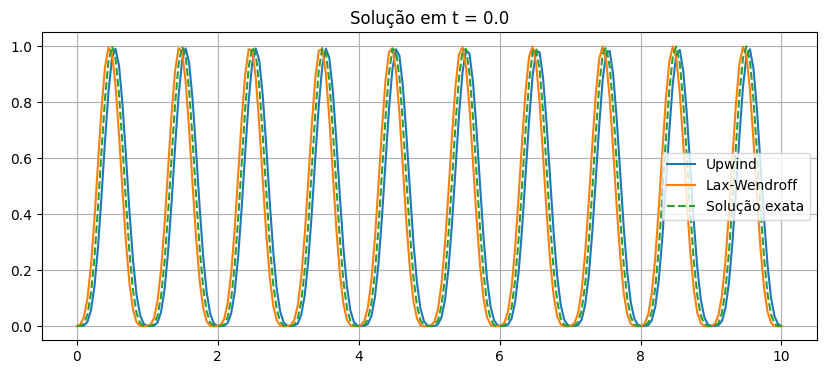

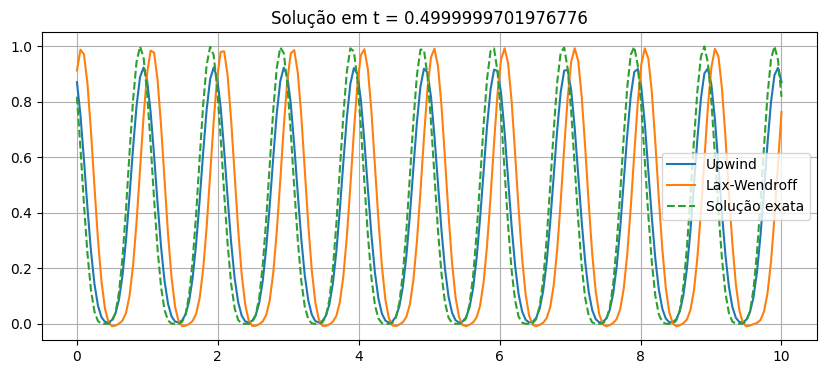

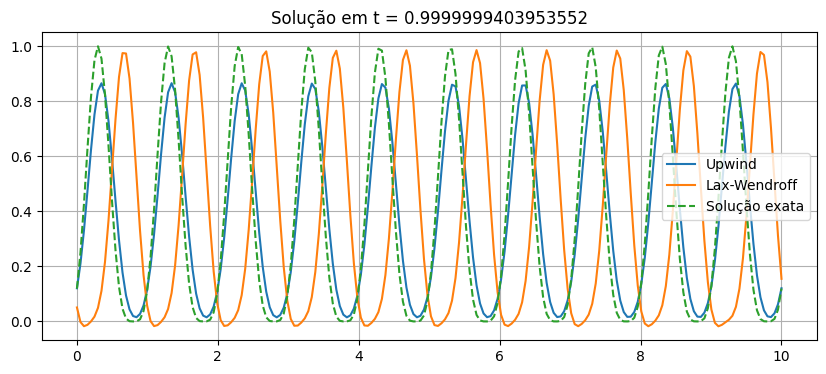

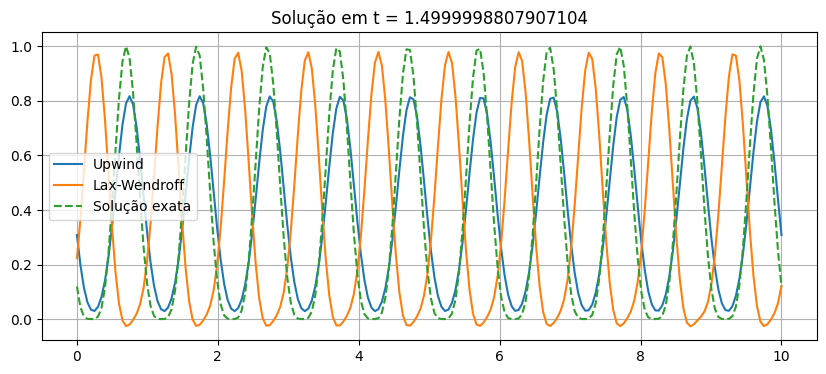

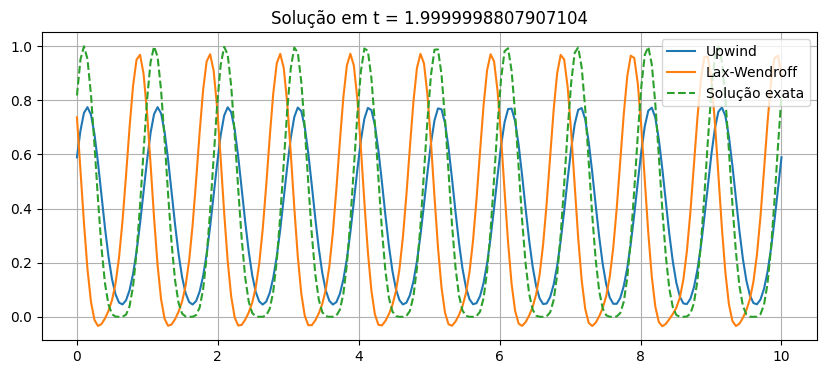

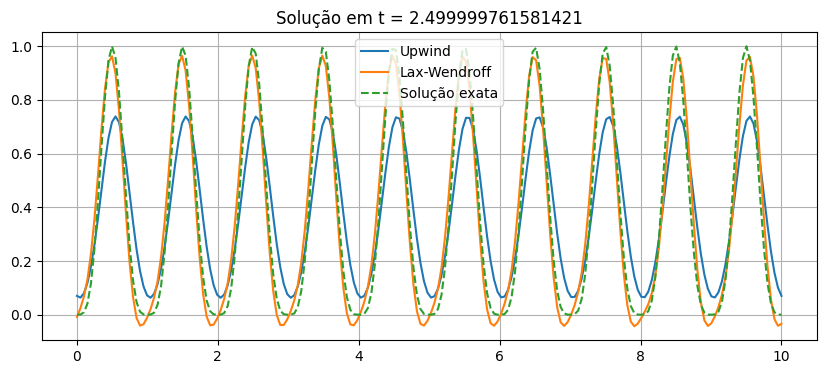

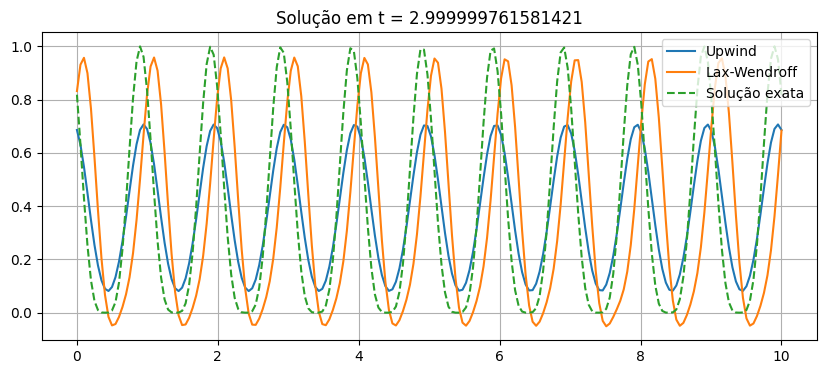

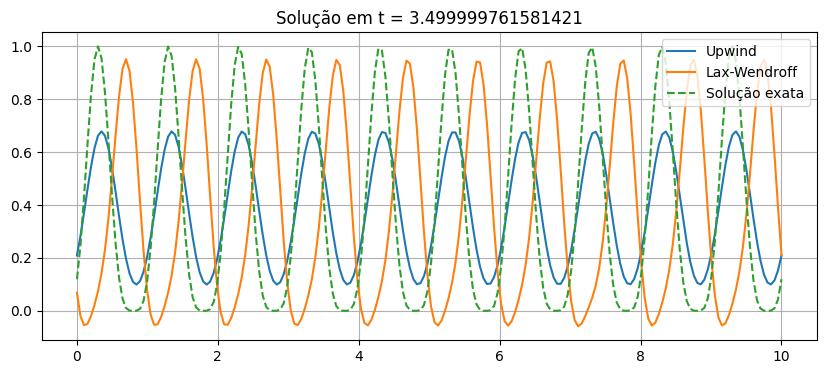

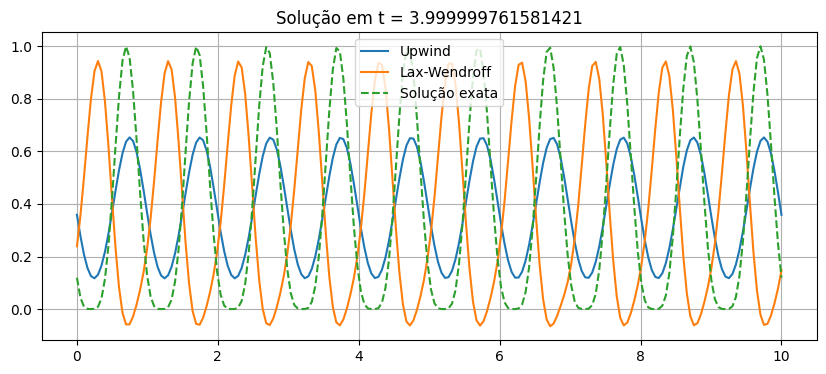

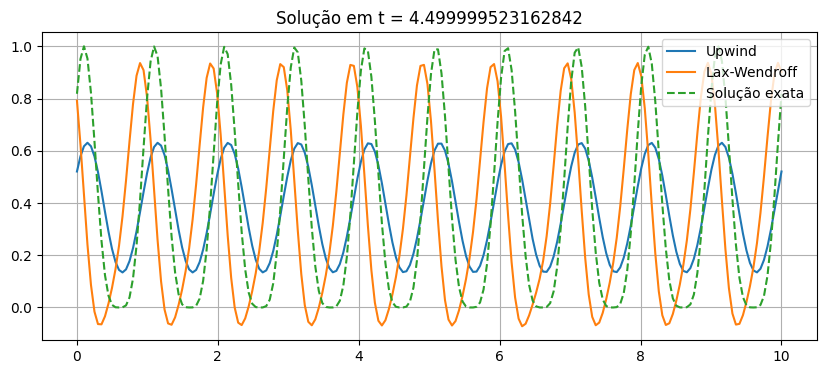

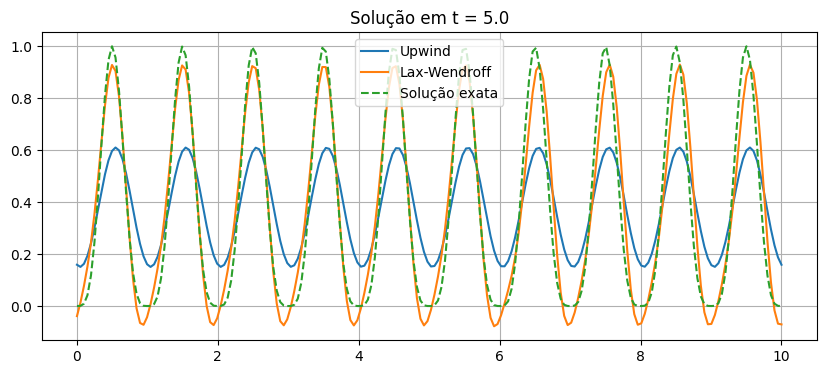

In [10]:

u_upwind = historico_upwind
u_lax_wendroff = historico_lax_wendroff


for i in range(len(t)):
        if i%10 == 0:
            plt.figure(figsize=(10,4))
            plt.plot(x,u_upwind[i],label = "Upwind")
            plt.plot(x,u_lax_wendroff[i],label = "Lax-Wendroff")
            plt.plot(x,solucao_exata(x,t[i],a,cond),label = 'Solução exata', linestyle = '--')
            plt.title("Solução em t = {}".format(t[i]))
            plt.legend()
            plt.grid(True)
            plt.show() 

            # plotar solução exata aqui dps tambem



